# PottsMPNN energy prediction

`run_energy_prediction` runs PottsMPNN's energy model over a structure and returns an
`EnergyPredictionResult`. With no mutant list it performs a **deep mutational scan** (every
position × every non-wild-type amino acid in each chain), which is exactly the data behind a
per-position mutation-energy heatmap.

The result object holds the per-mutation scores as a DataFrame (`.scores`) and can draw the
heatmap on demand with `.plot_heatmap()`.

> PottsMPNN is bundled as the `external/PottsMPNN` submodule; no path configuration is needed.

In [2]:
from pathlib import Path

# import torch

In [3]:
import snekwrap.config as config
from snekwrap.wrappers.pottsmpnn import run_energy_prediction

2026-07-01 14:33:26.060 | INFO     | snekwrap:<module>:2 - Importing snekwrap package
2026-07-01 14:33:26.061 | INFO     | snekwrap:<module>:3 - importing config
2026-07-01 14:33:26.540 | INFO     | snekwrap:<module>:5 - importing external wrappers
2026-07-01 14:33:26.541 | INFO     | snekwrap:<module>:7 - importing database_queries
2026-07-01 14:33:26.668 | INFO     | snekwrap:<module>:9 - importing sequence_utils


In [4]:


# Example PDBs ship with the PottsMPNN submodule.
example_pdbs = Path(config.POTTSMPNN_REPO) / "inputs" / "example_pdbs"
pdb = example_pdbs / "3dkm.pdb"  # small single-chain example, fast on CPU

# dev = "cuda" if torch.cuda.is_available() else "cpu"
dev = "cpu"
print(f"running on: {dev}")

running on: cpu


## Deep mutational scan

One call: pass the PDB (and any config as keyword arguments). The default model is
`vanilla_model_weights/pottsmpnn_msa_20.pt`; `ddG=True` returns energies relative to the
wild type (wild type centered at 0).

In [5]:
result = run_energy_prediction(pdb, dev=dev)

print("pdb:", result.pdb_name)
print("chains:", result.chain_order)
print("scored mutants:", len(result.scores))
result.scores.head()

100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


pdb: 3dkm
chains: ['A']
scored mutants: 1368


,pdb,mutant,wildtype,ddG_pred,ddG_expt
0,3dkm,ALYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,0.999756,NaN
1,3dkm,CLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,2.419434,NaN
2,3dkm,DLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,-0.686035,NaN
3,3dkm,ELYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,0.079102,NaN
4,3dkm,FLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,NLYFQGLKYMVPGARVTRGLDWKWRDQDGSPQGEGTVTGELHNGWI...,2.476562,NaN


## Heatmap

`plot_heatmap()` draws the [20 amino acids × positions] heatmap and **returns the matplotlib
`Figure`**, so you can customize it (titles, annotations, size) and re-save. Returning it as the
last line of a cell displays it; assign it (`fig = result.plot_heatmap()`) to modify it first.
Pass `save_path` to also write a PNG.

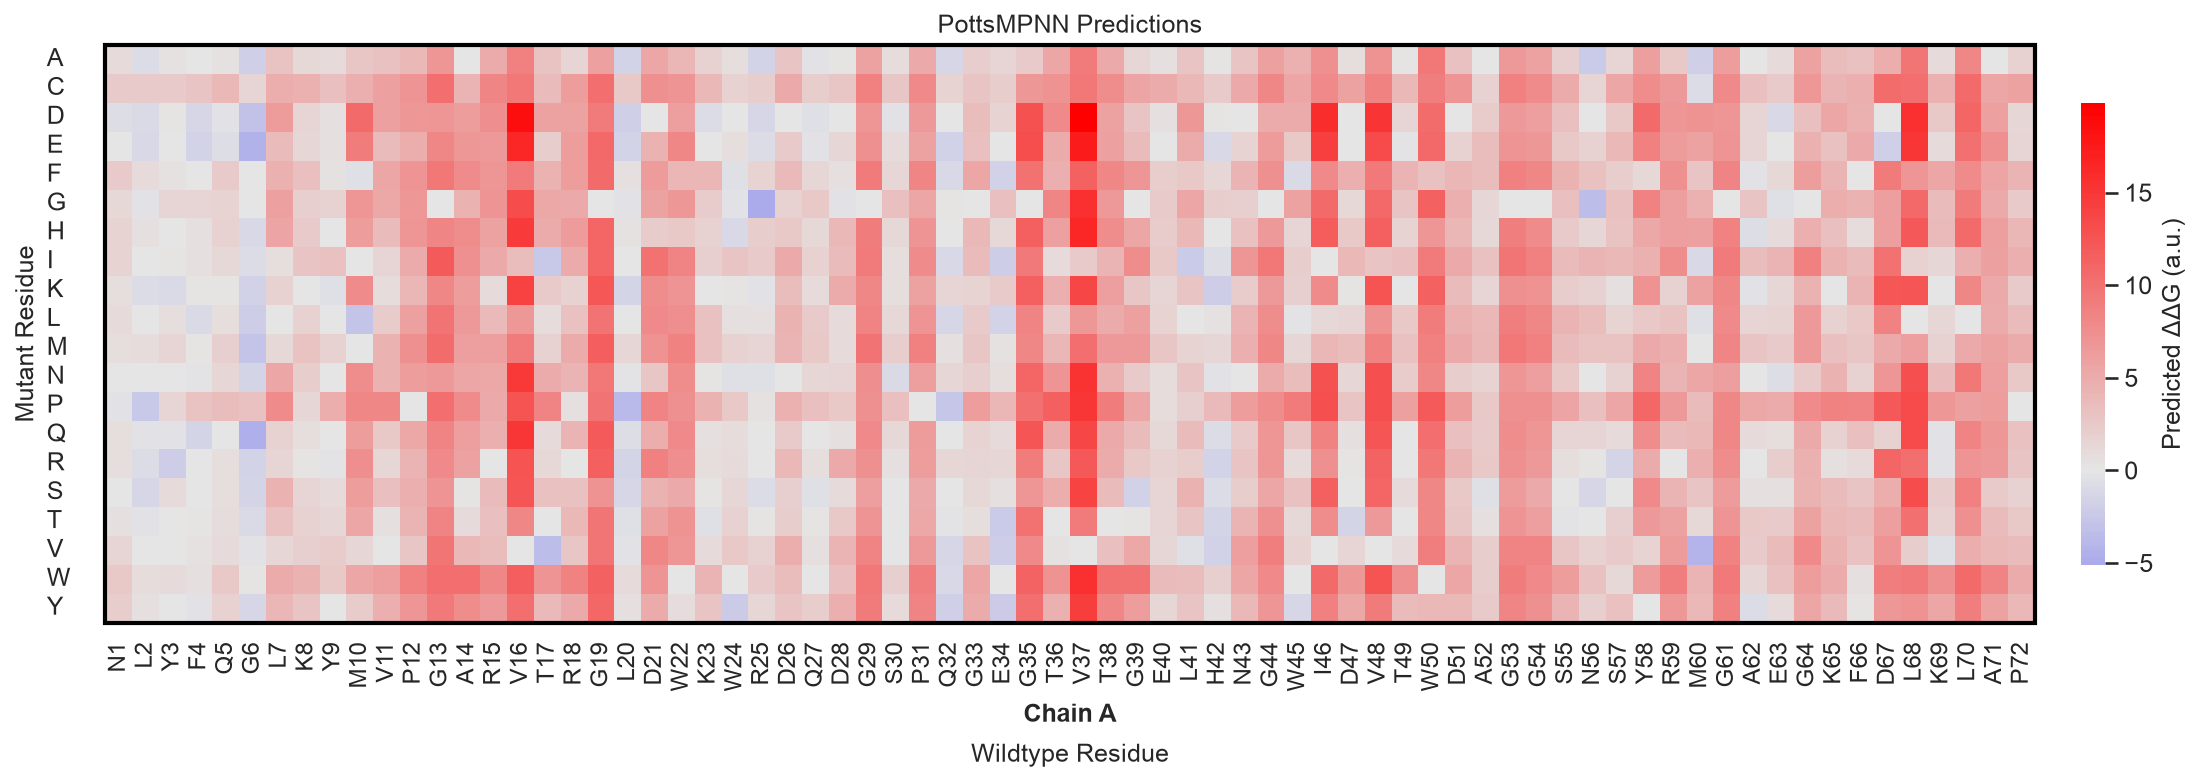

In [6]:
result.plot_heatmap()

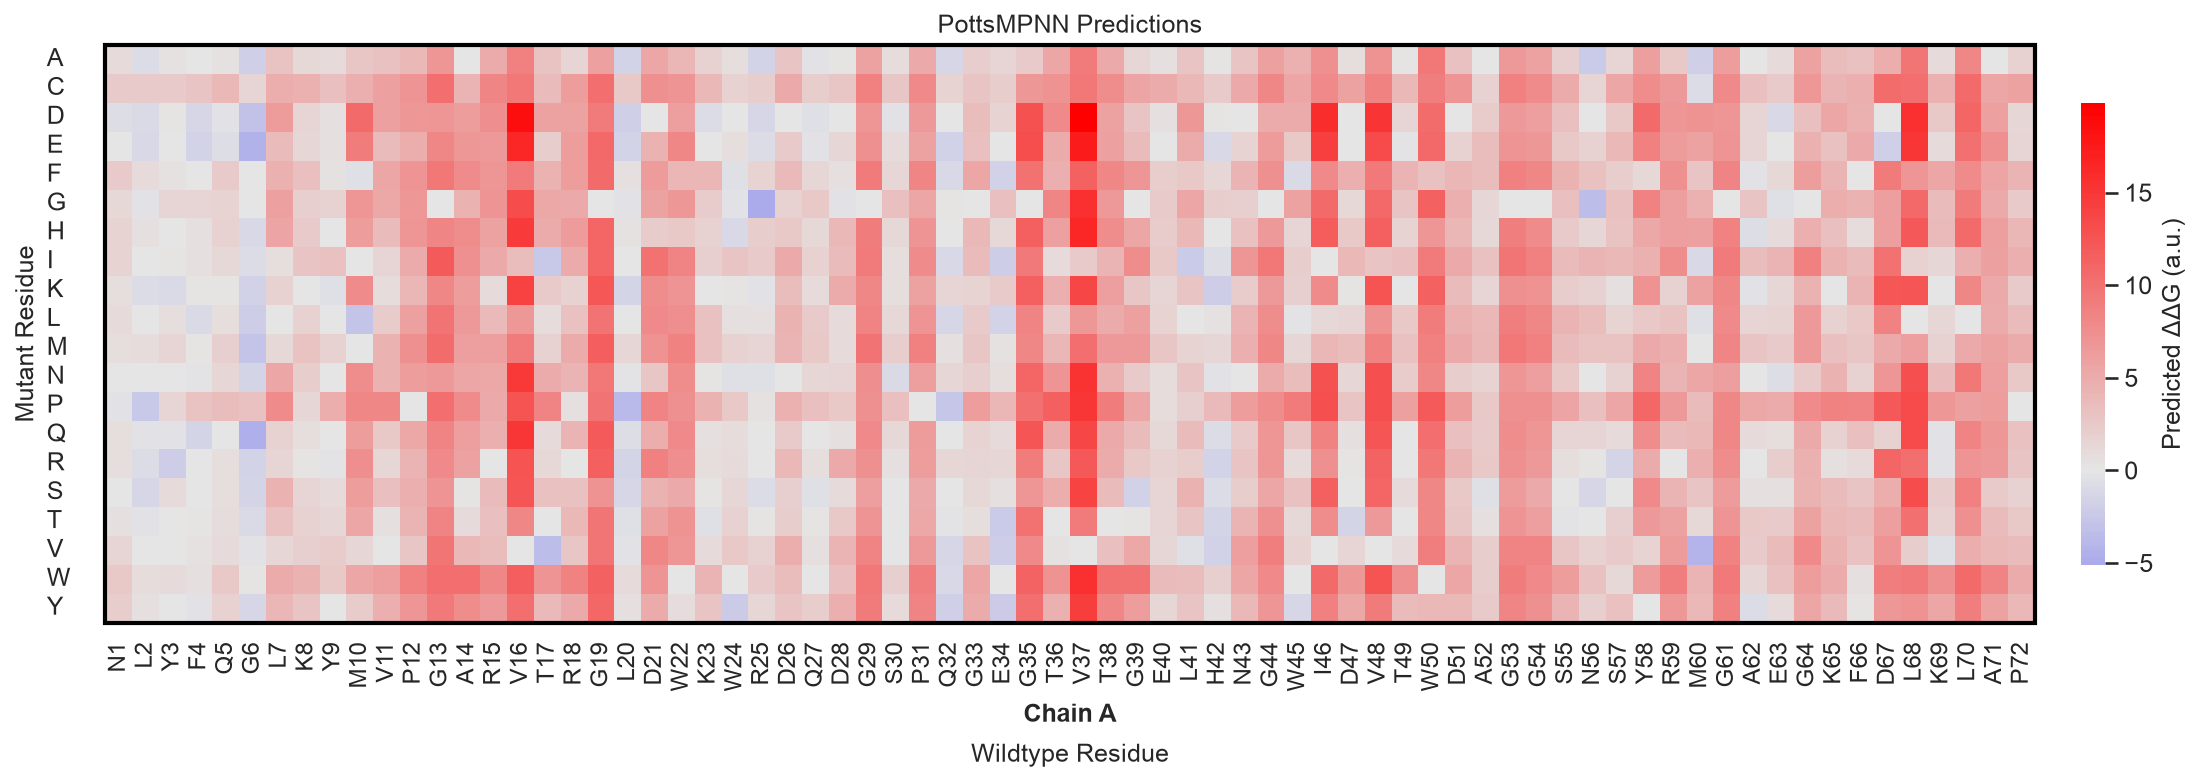

In [7]:
result.plot_heatmap(save_path="3dkm_ddg_heatmap.png")

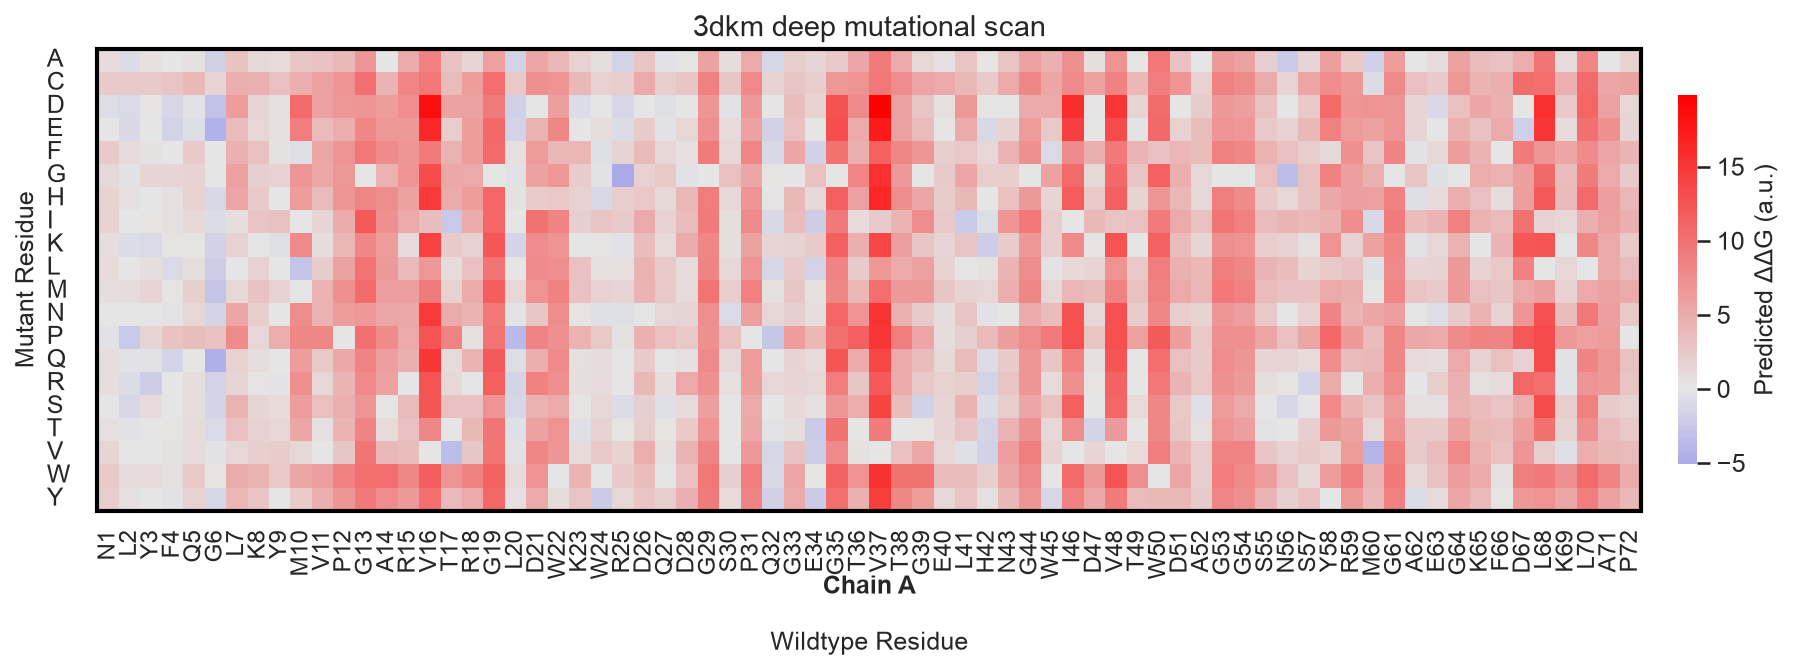

In [8]:
# plot_heatmap returns the Figure, so you can tweak it however you like
fig = result.plot_heatmap()
ax = fig.axes[0]  # the heatmap axes (fig.axes[1] is the colorbar)
ax.set_title("3dkm deep mutational scan", fontsize=14)
fig.set_size_inches(16, 4)
fig  # redisplay the modified figure

## Interactive heatmap

`plot_heatmap_interactive()` draws the same heatmap with **plotly** so you can hover a cell to
read the exact predicted energy for a given position/substitution, zoom, and pan. It returns a
plotly `Figure`.

The predictions are also available as plain data via `result.mutation_energies` — one tidy
`DataFrame` per chain (`position, wildtype, mutant, ddG_pred`), ready to filter/`groupby`/merge.

In [9]:
# Per-mutation energy predictions as tidy tables, one DataFrame per chain. No method call: it's a
# lazily-computed attribute. Slice it like any DataFrame, e.g. .query("position == 42").
result.mutation_energies["A"].head()

,position,wildtype,mutant,ddG_pred
0,1,N,A,0.999756
1,1,N,C,2.419434
2,1,N,D,-0.686035
3,1,N,E,0.079102
4,1,N,F,2.476562


In [10]:
# Interactive version: hover any cell to read its exact predicted energy. Returns a plotly
# Figure, so you can .show() it, restyle it, or re-save it. The same only_mutated_positions /
# chain_ranges options work here too.
fig = result.plot_heatmap_interactive(title="3dkm deep mutational scan")
fig

## Multi-chain complexes

For a complex you can restrict the scan to particular chains with `scan_chains`, and zoom
the heatmap to a position range per chain with `chain_ranges` (inclusive, 1-indexed).

`6w25` is a peptide (chain A) bound to a protein (chain B); here we scan only chain B.

100%|██████████| 1/1 [00:05<00:00,  5.04s/it]


chains: ['A', 'B'] | scored mutants: 8892


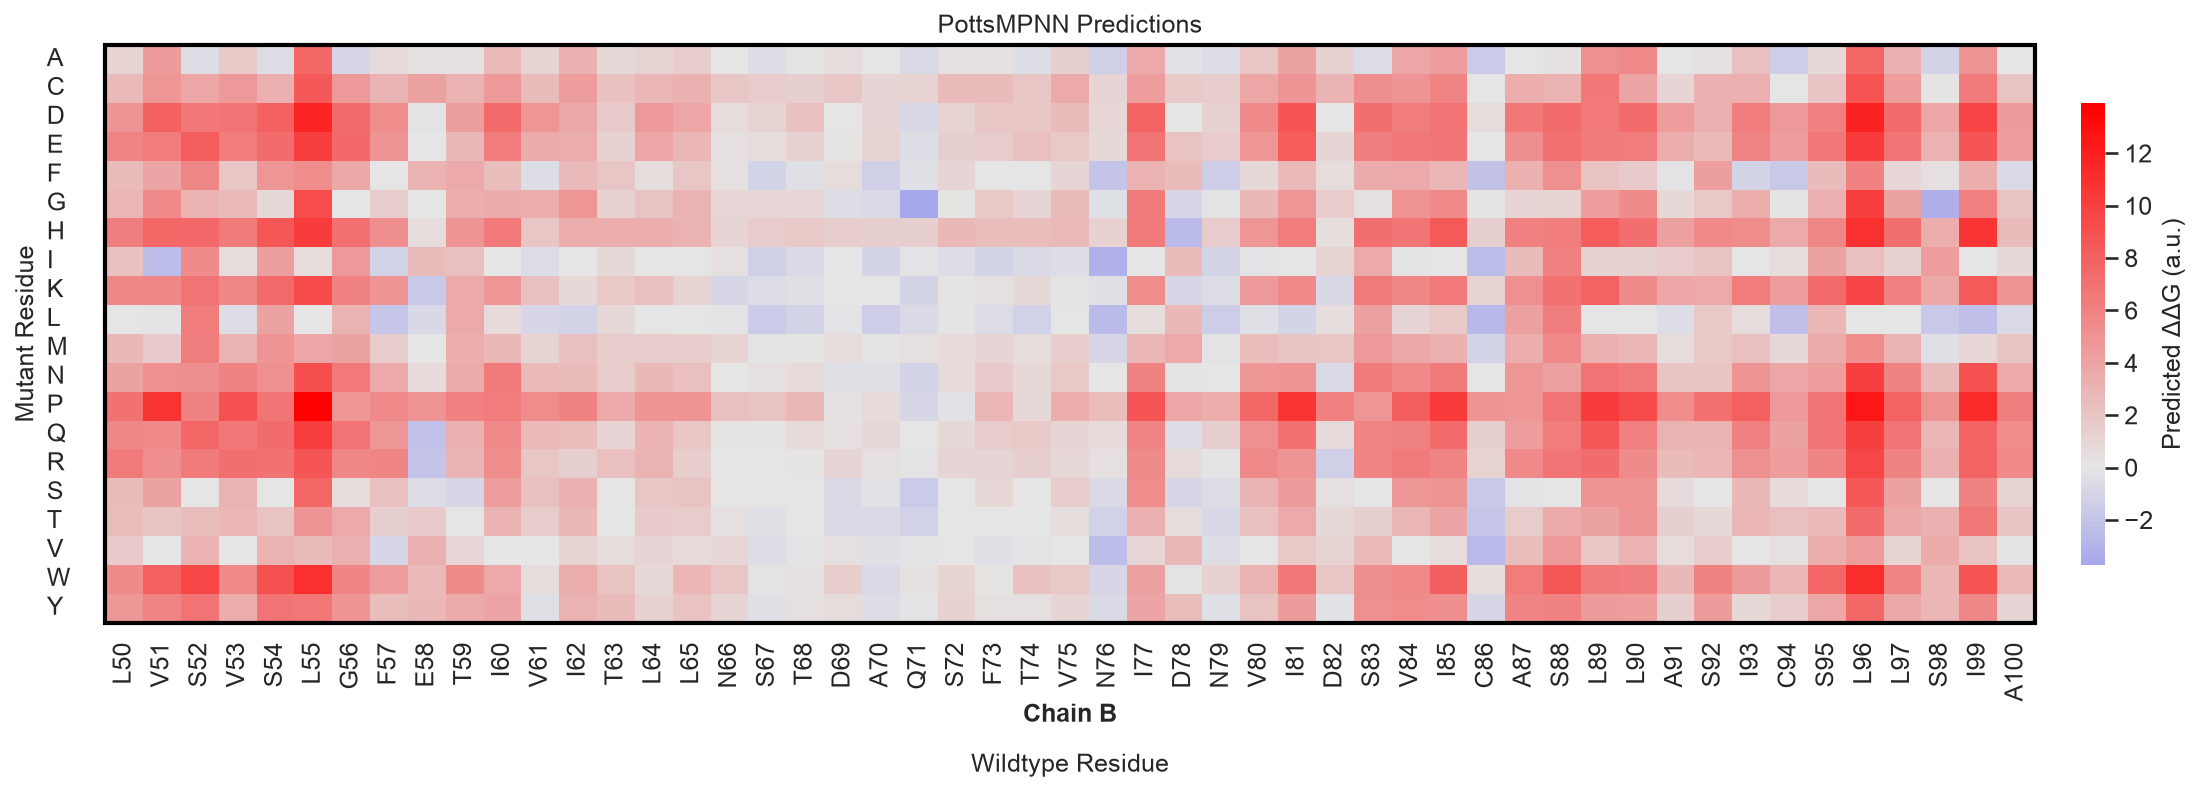

In [11]:
complex_result = run_energy_prediction(
    example_pdbs / "6w25.pdb",
    scan_chains=["B"],  # scan chain B only
    dev=dev,
)

print("chains:", complex_result.chain_order, "| scored mutants:", len(complex_result.scores))

# zoom the heatmap to chain B positions 50-100
complex_result.plot_heatmap(chain_ranges={"B": [50, 100]})

## Binding energy

To predict how mutations affect **binding** instead of stability, pass `binding_partitions` —
the chain partitions of the complex (its binding partners). The predicted value then becomes the
change in binding energy, E(bound) − Σ E(unbound partitions), so positive values indicate
mutations that weaken binding. The partitions must cover every chain in the structure exactly
once (every chain goes in exactly one group).

Here we scan the `6w25` peptide (chain A) and split the complex into the peptide `[A]` and its
receptor `[B]`. Since only chain A is scanned, we pass `only_mutated_positions=True` to
`plot_heatmap` so the heatmap shows just the scanned positions instead of every position in the
(much larger) receptor chain.

100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


binding ΔΔG predictions: 114


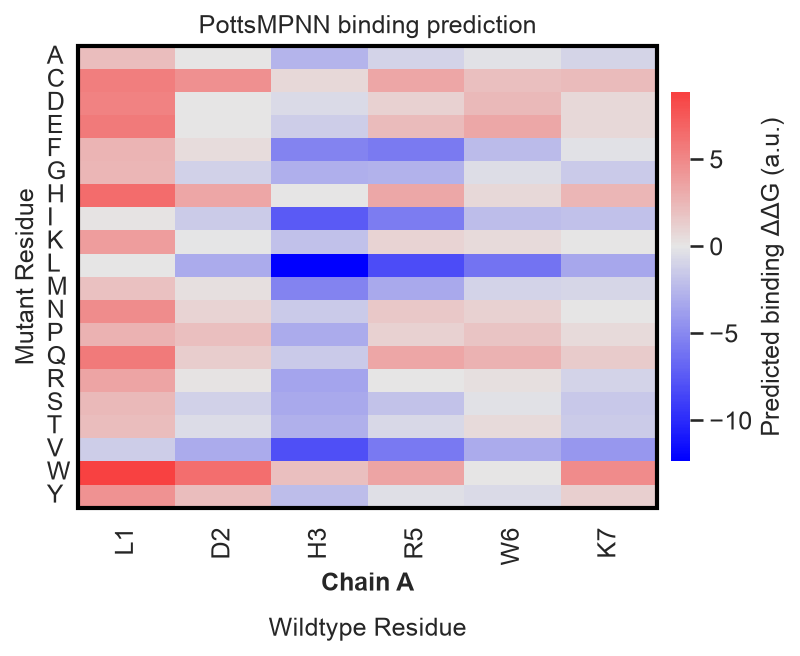

In [20]:
binding_result = run_energy_prediction(
    example_pdbs / "6w25.pdb",
    scan_chains=["A"],                  # scan the peptide (chain A)
    binding_partitions=[["A"], ["B"]],  # complex partitions: peptide [A] vs receptor [B]
    mean_norm=True,
    dev=dev,
)
print("binding ΔΔG predictions:", len(binding_result.scores))

# Only the peptide (chain A) was scanned, so use only_mutated_positions=True to drop the
# hundreds of un-scanned chain-B columns (otherwise the heatmap is mostly empty).
fig = binding_result.plot_heatmap(
    only_mutated_positions=True,
    title="PottsMPNN binding prediction",
    clabel=r"Predicted binding $\Delta\Delta$G (a.u.)",
)
fig.set_size_inches(6, 4)
fig

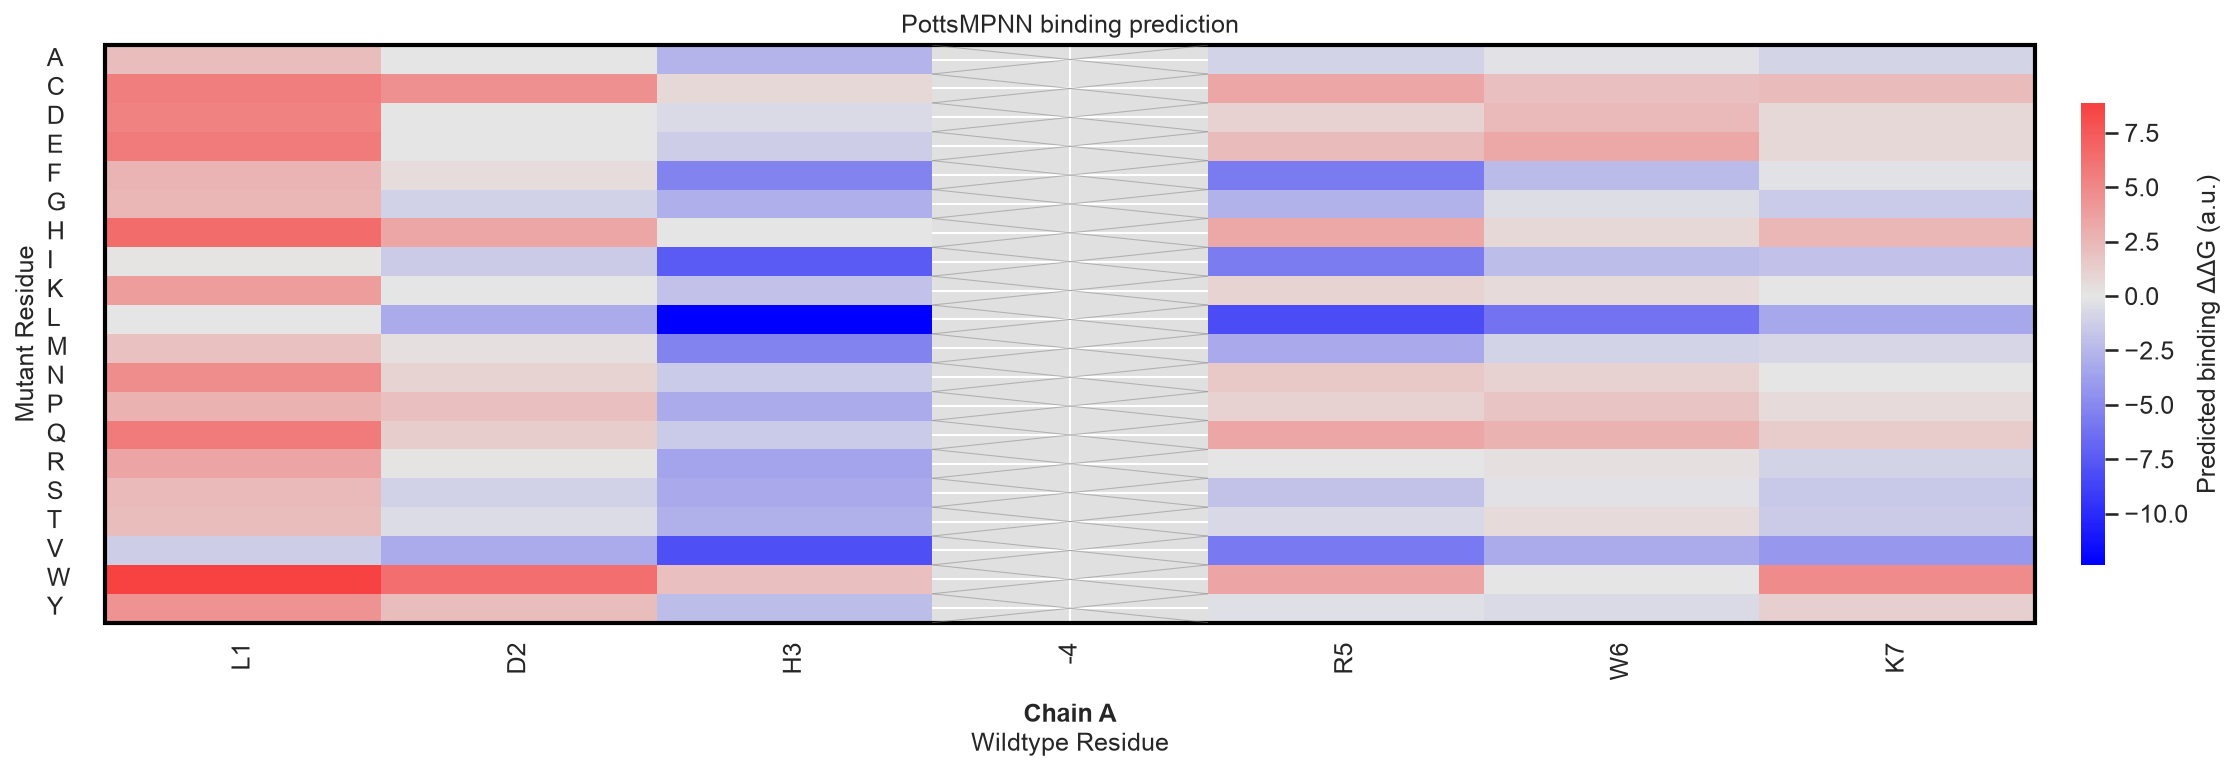

In [25]:
binding_result.plot_heatmap(
    chain_ranges={"A": [1, 20]},  # zoom to the peptide (chain A) positions
    title="PottsMPNN binding prediction",
    clabel=r"Predicted binding $\Delta\Delta$G (a.u.)",
)

In [13]:
binding_result.plot_heatmap_interactive(only_mutated_positions=True)

## On the structure

`view_structure()` colors each scanned residue on the 3-D structure by its **mean** predicted
energy (blue = stabilizing, red = destabilizing, centered at 0); residues that were never scanned
stay gray. It returns an nglview widget. Here, the peptide (chain A) residues are colored by their
mean binding ddG while the receptor (chain B) stays gray.

The underlying per-position numbers are available via `position_means()` (a Series per chain), and
`agg="min"` colors each position by its single most-stabilizing substitution instead of the mean.

In [14]:
binding_result = run_energy_prediction(
    "./1a22.pdb",
    scan_chains=["A"],                  # scan the peptide (chain A)
    binding_partitions=[["A"], ["B"]],  # complex partitions: peptide [A] vs receptor [B]
    mean_norm=True,
    dev=dev,
)
print("binding ΔΔG predictions:", len(binding_result.scores))

100%|██████████| 1/1 [00:02<00:00,  2.55s/it]


binding ΔΔG predictions: 3420


In [15]:
binding_result.position_means()

{'A': position
 1     -0.119854
 2     -0.150898
 3     -0.117901
 4     -0.175466
 5     -0.181531
          ...   
 187    0.118993
 188   -0.416780
 189    1.016094
 190    0.047293
 191   -0.126330
 Name: ddG_pred, Length: 180, dtype: float64}

In [16]:
binding_result.view_structure()

NGLWidget()

In [17]:
binding_result.view_structure(agg="min")

NGLWidget()

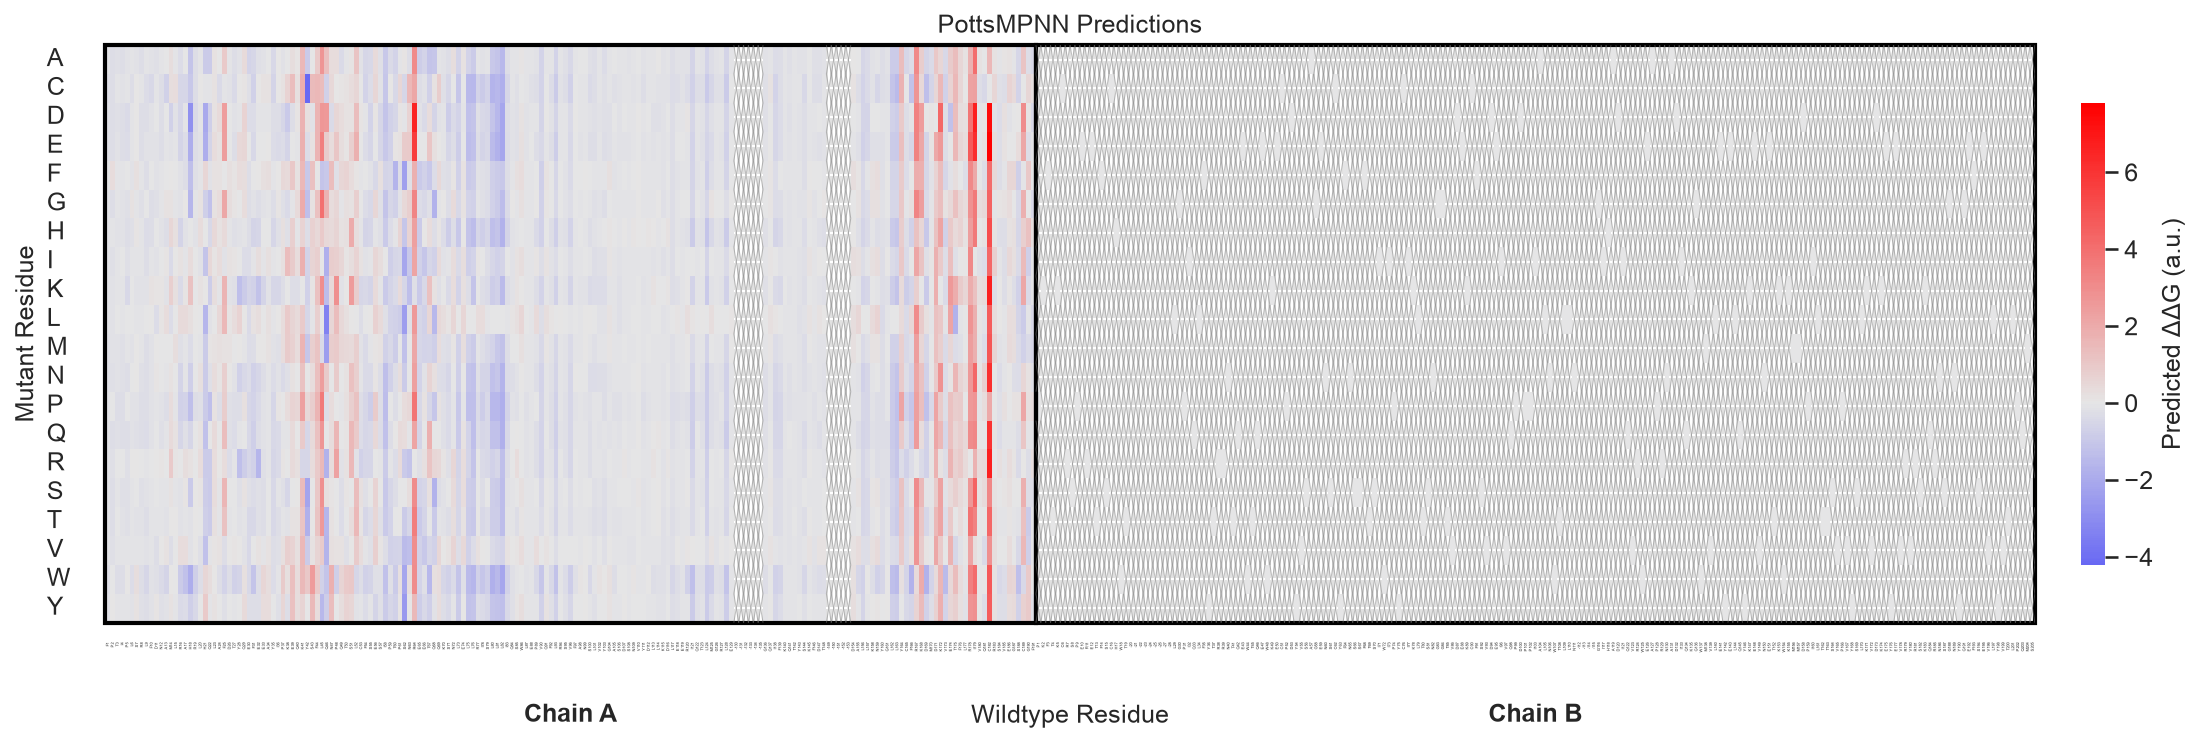

In [18]:
binding_result.plot_heatmap()

In [19]:
# from IPython.display import display
# import py3Dmol
# from io import StringIO
# from Bio.PDB import PDBIO, MMCIFParser, PPBuilder, Structure  # type: ignore
# from Bio import PDB
# import nglview as nv

# def show_structure_with_py3Dmol(structure: Structure.Structure, style: str="cartoon"):
#     """
#     Displays a Biopython Structure object using py3Dmol in a Jupyter environment.
#     """
#     # Write structure to a PDB string
#     pdb_buf = StringIO()
#     io = PDBIO()
#     io.set_structure(structure)
#     io.save(pdb_buf)
#     pdb_str = pdb_buf.getvalue()

#     # Visualize with py3Dmol
#     view = py3Dmol.view(width=600, height=400)
#     view.addModel(pdb_str, "pdb")
#     view.setStyle({style: {}})
#     view.zoomTo()
#     display(view)


# def show_structure_with_nglview(structure: Structure.Structure, style: str="cartoon", highlight_cysteines: bool=False):
#     """
#     Displays a Biopython Structure object using nglview in a Jupyter environment.
#     """
#     import nglview as nv

#     # Write structure to a PDB string
#     pdb_buf = StringIO()
#     io = PDBIO()
#     io.set_structure(structure)
#     io.save(pdb_buf)
#     pdb_str = pdb_buf.getvalue()

#     # Visualize with nglview
#     view = nv.NGLWidget()
#     view.add_component(nv.TextStructure(pdb_str), ext="pdb")
#     view.clear_representations()
#     view.add_representation(style)
#     if highlight_cysteines:
#         view.add_representation(
#             "ball+stick",
#             selection="protein AND CYS",
#             color="yellow",
#         )
#     view.center()
#     display(view)


# def import_structure_biopython(pdb_file: str | Path) -> Structure.Structure:
#     pdb_file = Path(pdb_file)
#     parser = PDB.PDBParser(QUIET=True)
#     structure = parser.get_structure("protein", pdb_file)
#     return structure
# s = import_structure_biopython(example_pdbs / "6w25.pdb")
# show_structure_with_py3Dmol(s, style="cartoon")